In [18]:
import numpy as np
import xarray as xr
from dask.distributed import Client
from dask.diagnostics import ProgressBar
%load_ext line_profiler

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


In [1]:
import numpy as np
a = np.load("SP.npy")
b = np.load("DP.npy")

In [11]:
u, c = np.unique(b, return_counts=True)
import struct
def binary(num):
    return ''.join('{:0>8b}'.format(c) for c in struct.pack('!f', num))
f"{u[0]:.10e}"

'5.0247592544e-17'

# The triangle tradeoff of code

- Velocity: adding new features / capabilities to your code
- Adaptability: future-proofness of your current code. Hardest point imo, you don't have a crystal ball so you don't know what to adapt to, and too much adaptability may make velocity worse in the future
- Performance: how fast the code actually runs. What we are talking about today. Might come in conflict with the two others, and not necessarily the most important

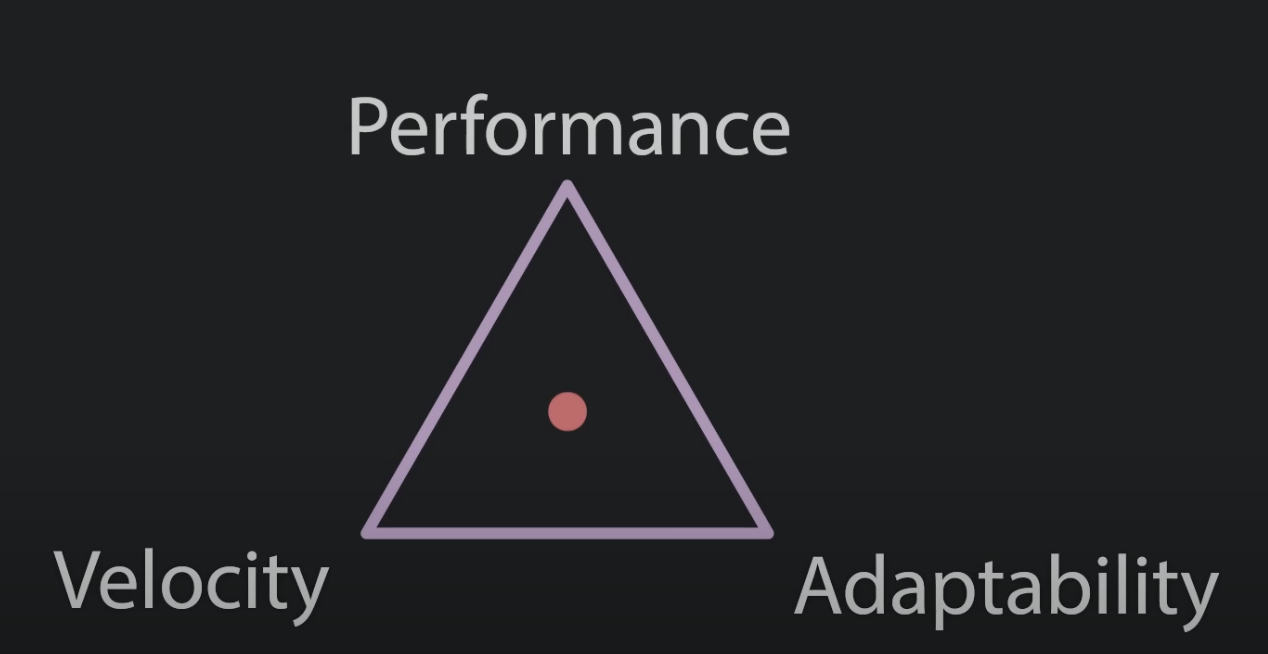

from Code Aesthetic "Premature optimization is the root of all evil" https://www.youtube.com/watch?v=tKbV6BpH-C8

# What is fast, what is slow

Slow:
- loops
- finding things in lists: `x in l`
- adding or removing stuff from sets (need a new object)
- ...

Fast:
- comprehensions: `[a + 1 for a in mylist]`
- finding things in sets: `x in s`
- adding or removing stuff from lists
- ...

You can find time complexities at https://wiki.python.org/moin/TimeComplexity and it's quite useful

# Find bottlenecks with profilers

In [19]:
from time import sleep, perf_counter
def myfunction():
    sleep(2)
    sleep(3)
    sleep(0.3)
    
%lprun -f myfunction myfunction()

*** KeyboardInterrupt exception caught in code being profiled.

Timer unit: 1e-09 s

Total time: 3.39597 s
File: /var/folders/zb/qrvsjg590771qgw5yhnx1vmw0000gn/T/ipykernel_55951/2014408307.py
Function: myfunction at line 2

Line #      Hits         Time  Per Hit   % Time  Line Contents
     2                                           def myfunction():
     3         1 2005056000.0    2e+09     59.0      sleep(2)
     4         1 1390911000.0    1e+09     41.0      sleep(3)
     5                                               sleep(0.3)

# Use compiled code

Baseline example of slow code

In [ ]:
a = np.random.randint(1, 50, int(1e8)).tolist()
b = []
t = perf_counter()
for element in a:
    b.append(element ** 2)
print(perf_counter() - t)

5.203449542001181


## Map
prettier but not much faster if you need a list as an output

In [ ]:
import numpy as np
a = np.random.randint(1, 50, int(1e8)).tolist()
b = []
t = perf_counter()
b = list(map(lambda x: x ** 2, a))
print(perf_counter() - t)

4.000032457995985


## Numpy and others
What you should be using

In [ ]:
a = np.random.randint(1, 50, int(1e8))
t = perf_counter()
b = a ** 2
print(perf_counter() - t)

0.853118999999424


## Vectorized calculations random tricks and recipes

### Pairwise outer operations

In [ ]:
# Pairwise difference between elements of b and a:
a = np.random.randint(0, 50, 1000)
b = np.random.randint(0, 50, 100)
pairwise_diff = (b[:, None] - a[None, :])
# pairwise_diff[i, j] is b[i] - a[j]

### Sort and argsort with only 1 sort, for 2+D arrays

In [ ]:
a = np.random.randint(0, 50, (100, 100))
# Instead of 
sorted_order_axis1 = np.argsort(a, axis=1)
sorted_axis1 = np.sort(a, axis=1)

# You can save a sort by doing
sorted_order_axis1 = np.argsort(a, axis=1)
sorted_axis1 = np.take_along_axis(a, sorted_order_axis1, axis=1)

### My favourite numpy function
Usecase: bin data, very useful for all kinds of stats applications

In [ ]:
unique, counts, indices = np.unique(a, return_counts=True, return_index=True)

### Structured numpy array: for array of tuples
(among other things)

Usecase: find all unique pairs in a list of tuples

In [ ]:
a = np.asarray([(1, 2), (3, 4), (1, 2)], dtype="i, i")
print(a)
print(np.unique(a))

[(1, 2) (3, 4) (1, 2)]
[(1, 2) (3, 4)]


Real world example: 2 2d array (maps) of ints ranging from 1 to 7, representing some spatial distribution at time $t$ and then later at time $t + 1$
We want to know the transition rate 1 -> 1, 1 -> 2, ..., 7 -> 7 between those two timesteps
One fast way to do it is using an array of tuples

In [ ]:
a = np.random.randint(0, 7, size=(64, 64)).flatten()
b = np.random.randint(0, 7, size=(64, 64)).flatten()
# Turn into a list of tuples, each tuple is (sample at t, sample at t+1) at the same position in the 2d map
arr = list(map(tuple, np.stack([a, b], axis=1)))
# Turn into a 1D structured array of tuples to keep the tuple structure instead of a normal 2D numpy array
arr = np.asarray(arr, dtype="i, i") # "i, i" is for "int, int"
# My favourite function <3
unique, counts = np.unique(arr, return_counts=True)
dict(zip(unique.tolist(), counts))

{(0, 0): 86,
 (0, 1): 84,
 (0, 2): 87,
 (0, 3): 71,
 (0, 4): 82,
 (0, 5): 80,
 (0, 6): 81,
 (1, 0): 78,
 (1, 1): 81,
 (1, 2): 79,
 (1, 3): 94,
 (1, 4): 95,
 (1, 5): 88,
 (1, 6): 77,
 (2, 0): 75,
 (2, 1): 94,
 (2, 2): 86,
 (2, 3): 83,
 (2, 4): 86,
 (2, 5): 86,
 (2, 6): 83,
 (3, 0): 79,
 (3, 1): 97,
 (3, 2): 88,
 (3, 3): 80,
 (3, 4): 84,
 (3, 5): 77,
 (3, 6): 88,
 (4, 0): 83,
 (4, 1): 80,
 (4, 2): 74,
 (4, 3): 91,
 (4, 4): 82,
 (4, 5): 78,
 (4, 6): 74,
 (5, 0): 92,
 (5, 1): 92,
 (5, 2): 87,
 (5, 3): 71,
 (5, 4): 93,
 (5, 5): 73,
 (5, 6): 88,
 (6, 0): 85,
 (6, 1): 80,
 (6, 2): 94,
 (6, 3): 79,
 (6, 4): 85,
 (6, 5): 86,
 (6, 6): 80}

# Multiprocessing, homemade

In [ ]:
from multiprocessing import Pool
from def_f import f
a = np.random.randint(1, 50, int(1e8)).tolist()

t = perf_counter()
with Pool(16) as p:
    b = p.map(f, a, chunksize=1000000) # chunksize is very important
print(perf_counter() - t)

4.564064624995808


Sometimes helps sometimes not

If the order doesn't matter, or you have other ways to recover it, `imap` can be a better choice

In [ ]:
t = perf_counter()
with Pool(16) as p:
    b = p.imap(f, a, chunksize=1000000) # chunksize is very important
print(perf_counter() - t)

0.14142120799806435


# Dask

In [20]:
a = np.random.randint(1, 50, (int(1e5), int(1e4)))
da = xr.DataArray(a, dims=("x", "y"))
da = da.chunk("auto")
da

<xarray.DataArray (x: 100000, y: 10000)> Size: 8GB
dask.array<xarray-<this-array>, shape=(100000, 10000), dtype=int64, chunksize=(4096, 4096), chunktype=numpy.ndarray>
Dimensions without coordinates: x, y

In [21]:
da ** 2 # does not actually compute

<xarray.DataArray (x: 100000, y: 10000)> Size: 8GB
dask.array<pow, shape=(100000, 10000), dtype=int64, chunksize=(4096, 4096), chunktype=numpy.ndarray>
Dimensions without coordinates: x, y

In [ ]:
(da ** 2).compute() # to compute

[########################################] | 100% Completed | 2.57 sms


In [ ]:
with ProgressBar():
    (da ** 2).compute(n_workers=15) # to compute

[########################################] | 100% Completed | 2.80 sms


In [ ]:
with Client(n_workers=15, memory_limit="0.2GiB"):
    (da ** 2).compute() # to compute

[########################################] | 100% Completed | 1.97 sms


NB: dask is terrible at respecting memory limitations, you need to set `n_workers` accordingly

# Make your own compiled code with numba+numpy

When you can't find a fast numpy function to do fast things functions, the best way forward is to write your own!

Comes with many caveats: **no list**, everything needs to be preallocated (fixed-size numpy array), some functions don't work including `np.unique(..., return_counts=True)` or `np.amax(a, axis=1)`. very sad.

In [ ]:
from numba import njit
from typing import Optional
from nptyping import NDArray


@njit
def distance(x1: float, x2: float, y1: float, y2: float) -> float:
    dx = x2 - x1
    if np.abs(dx) > 180:
        dx = 360 - np.abs(dx)  # sign is irrelevant
    dy = y2 - y1
    return np.sqrt(dx**2 + dy**2)


def my_pairwise(X: NDArray) -> NDArray:
    x = X[:, 0]
    y = X[:, 1]
    output = np.zeros((len(X), len(X)))
    for i in range(X.shape[0] - 1):
        for j in range(i + 1, X.shape[0]):
            output[i, j] = distance(x[j], x[i], y[j], y[i])
            output[j, i] = output[i, j]
    return output


@njit
def my_pairwise_jit(X: NDArray) -> NDArray:
    x = X[:, 0]
    y = X[:, 1]
    output = np.zeros((len(X), len(X)))
    for i in range(X.shape[0] - 1):
        for j in range(i + 1, X.shape[0]):
            output[i, j] = distance(x[j], x[i], y[j], y[i])
            output[j, i] = output[i, j]
    return output


def my_pairwise_numpy(X: NDArray) -> NDArray:
    x = X[:, 0]
    y = X[:, 1]
    dx = x[:, None] - x[None, :]
    absdx = np.abs(dx)
    dx = np.where(absdx > 180, 360 - absdx, dx)
    dy = y[:, None] - y[None, :]
    return np.sqrt(dx ** 2 + dy ** 2)


size = int(5e3)
x = np.random.rand(size) * 360 - 180 # lon
y = np.random.rand(size) * 180 - 90  # lat
X = np.stack([x, y], axis=1)

print("No just in time compilation")
t = perf_counter()
my_pairwise(X)
print(f"{perf_counter() - t:.4f}s")
print("")

print("With just in time compilation")
t = perf_counter()
my_pairwise_jit(X)
print(f"{perf_counter() - t:.4f}s")
print("")

print("Just numpy tricks")
t = perf_counter()
my_pairwise_numpy(X)
print(f"{perf_counter() - t:.4f}s")


No just in time compilation
7.1712s

With just in time compilation
0.1074s

Just numpy
0.2321s


# Further: Write c++ or fortran functions and call them in python!

For example using https://github.com/pybind/pybind11. Careful with array views! Python lets you not care about this most of the time, but `a[:, :40]` is not the same as `a[:, :40].copy()`. 

C++ and fortran will not let you get away with carelessness. So only use them if you have no other choice.